In [6]:
!pip install -q langchain langchain-openai pydantic networkx matplotlib

import os
from google.colab import userdata

os.environ["DEEPSEEK_API_KEY"] = userdata.get('DEEPSEEK_API_KEY')

In [20]:
!pip install -U langchain-openai langchain-core --force-reinstall

  Using cached langchain_openai-1.2.2-py3-none-any.whl.metadata (3.1 kB)
  Using cached langchain_core-1.4.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached langchain_protocol-0.0.15-py3-none-any.whl.metadata (2.4 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.0 MB/s eta 0:00:00
Using cached langchain_openai-1.2.2-py3-none-any.whl (99 kB)
Using cached langchain_core-1.4.0-py3-none-any.whl (548 kB)
Using cached langchain_protocol-0.0.15-py3-none-any.whl (7.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.6/399.6 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
from langchain_openai import ChatOpenAI

### 1. Model Configuration and Input Data Preparation

In the cell below, we perform two key operations:

1. **LLM (Large Language Model) Initialization:** We use the `ChatOpenAI` class from the LangChain library, but via the `base_url` parameter, we redirect the requests to the **DeepSeek** API (using the `deepseek-chat` model). Setting `temperature=0.0` is very important here – it ensures that the model's responses are highly deterministic, reproducible, and precise (we limit its "creativity" and hallucinations, which is crucial for data extraction).
2. **Source Text Definition:** We create a `medical_text` variable containing a raw, unstructured medical note about a patient. This will serve as our baseline for further Information Extraction experiments.

In [7]:
llm = ChatOpenAI(
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com",
    model="deepseek-chat",
    temperature=0.0
)

medical_text = """
Patient John Smith, 45 years old, visited Dr. Nowak on May 12, 2026.
Diagnosis: Hypertension.
Prescribed medication: Lisinopril 10mg.
John Smith is also allergic to Penicillin and peanuts.
"""

print("Input text to analyze:\n", medical_text)

Input text to analyze:
 
Patient John Smith, 45 years old, visited Dr. Nowak on May 12, 2026.
Diagnosis: Hypertension.
Prescribed medication: Lisinopril 10mg.
John Smith is also allergic to Penicillin and peanuts.



### 2. Baseline Information Extraction (Naive Prompting)

In this step, we test the model's basic ability to extract information using a simple, straightforward prompt.

* **Naive Prompt:** We construct a basic natural language request asking the model to find specific entities (patient, doctor, diagnosis, medications) within the provided text.
* **The Result:** The model successfully identifies the correct details and formats them nicely for a human reader.
* **The Limitation:** Notice that the output is **unstructured text** (a plain string containing markdown bullets and conversational filler like *"Here is the information extracted..."*). While easy for us to read, this format is highly impractical to process programmatically, save to a database, or use in an automated pipeline without writing brittle parsing scripts.

In [8]:
naive_prompt = f"List the patient, doctor, diagnosis, and medications from this text: {medical_text}"
naive_response = llm.invoke(naive_prompt)

print("Model Response (Unstructured):")
print(naive_response.content)

Model Response (Unstructured):
Here is the information extracted from the text:

- **Patient:** John Smith
- **Doctor:** Dr. Nowak
- **Diagnosis:** Hypertension
- **Medications:** Lisinopril 10mg


### 3. Structured Information Extraction (Prompt Engineering)

To solve the unstructured data problem, we introduce **Prompt Engineering** combined with strict output parsing to force the model to return machine-readable data.

* **Defining the Schema (Pydantic):** We define a `MedicalRelation` class. This acts as a rigid blueprint, telling the model exactly what fields to extract, their specific data types (e.g., strings vs. lists), and what they mean.
* **Output Parser:** We use LangChain's `PydanticOutputParser`. It does two things: it automatically injects strict JSON formatting instructions into our prompt (`{format_instructions}`), and it validates/parses the raw text response back into a structured Python object.
* **The LCEL Chain:** We seamlessly link the prompt, the LLM, and the parser together (`prompt | llm | parser`) using LangChain Expression Language.
* **The Result:** The output is now a clean, perfectly formatted **JSON object**. Unlike the previous naive approach, this structured data is ready to be directly saved to a database, sent to an API, or used to build a Knowledge Graph.

In [9]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser

class MedicalRelation(BaseModel):
    patient: str = Field(description="Full name of the patient")
    doctor: str = Field(description="Full name of the attending physician")
    disease: str = Field(description="The diagnosed medical condition")
    medications: list[str] = Field(description="List of prescribed medications")
    allergies: list[str] = Field(description="List of allergens. Return an empty list if none.")

knowledge_parser = PydanticOutputParser(pydantic_object=MedicalRelation)

prompt_template = ChatPromptTemplate.from_messages([
    ("system", "You are an impersonal system for medical knowledge extraction.\n\n{format_instructions}"),
    ("human", "Text: {text}")
])

chain = prompt_template | llm | knowledge_parser

engineering_result = chain.invoke({
    "text": medical_text,
    "format_instructions": knowledge_parser.get_format_instructions()
})

print("Engineering Result (Ready for Database):")
print(engineering_result.model_dump_json(indent=2))

Engineering Result (Ready for Database):
{
  "patient": "John Smith",
  "doctor": "Dr. Nowak",
  "disease": "Hypertension",
  "medications": [
    "Lisinopril 10mg"
  ],
  "allergies": [
    "Penicillin",
    "peanuts"
  ]
}


### 4. Knowledge Graph Construction and Visualization

In this step, we take the perfectly structured JSON data we just extracted and transform it into a functional **Knowledge Graph**.

* **Graph Initialization (`nx.DiGraph`):** We use the `networkx` library in Python to create a Directed Graph. This means the connections between our entities have a specific, logical direction (e.g., a Doctor *prescribes* a Medication, not the other way around).
* **Building Semantic Triplets (`G.add_edge`):** We map the parsed data into relationships known as triplets (Node A -> Relationship -> Node B). For example, we create an edge from the `patient` node to the `disease` node and label it `"suffers from"`.
* **Handling Lists:** By using simple `for` loops, we dynamically generate edges for lists of items, seamlessly linking the patient to every individual allergen or medication found in the text.
* **Visualization (`matplotlib`):** Finally, we render the graph visually. This plot perfectly illustrates how isolated text is transformed into an interconnected web of knowledge—which is exactly the foundational data structure you need to build a **Graph RAG** system!

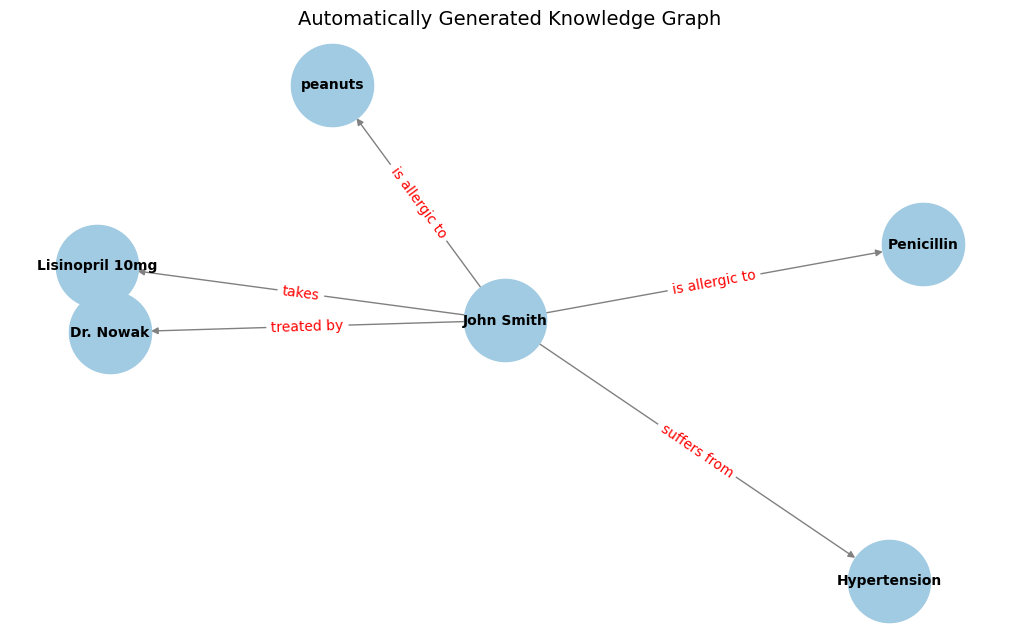

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

G.add_edge(engineering_result.patient, engineering_result.disease, label="suffers from")
G.add_edge(engineering_result.patient, engineering_result.doctor, label="treated by")

for med in engineering_result.medications:
    G.add_edge(engineering_result.doctor, med, label="prescribes")
    G.add_edge(engineering_result.patient, med, label="takes")

for allergy in engineering_result.allergies:
    G.add_edge(engineering_result.patient, allergy, label="is allergic to")

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, with_labels=True, node_color='#A0CBE2', node_size=3500,
        font_size=10, font_weight="bold", edge_color='gray', arrows=True)

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Automatically Generated Knowledge Graph", fontsize=14)
plt.show()

### 5. Advanced Prompt Engineering (Extracting Explicit Triplets)

To build a robust Knowledge Graph, extracting just the entities (nodes) isn't enough; we also need to extract the exact relationships (edges) between them. In this step, we refine our schema to extract complete, graph-ready **triplets** (Subject $\rightarrow$ Predicate $\rightarrow$ Object).

* **Enhanced Schema:** We updated the `MedicalRelation` Pydantic class to include relationship-specific fields like `condition_relation` and `medication_relation`.
* **Constraining the Model's Vocabulary:** Notice the `Field` descriptions—we strictly limit the allowed values (e.g., *"Use ONLY: 'prescribes' or 'recommends'"*). This prevents the LLM from inventing random relationship names, ensuring consistency for our database schema.
* **Strict System Prompting:** We introduced a robust `system_instruction` block with "STRICT RULES" to force the model into the role of a deterministic Knowledge Engineering tool, handling edge cases like missing data gracefully.
* **The Result:** The JSON output now cleanly defines both the nodes (John Smith, Hypertension, Lisinopril) and the standardized edges connecting them. This data is perfectly formatted to be ingested directly into a Graph Database like Neo4j!

In [11]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser
from typing import List

class MedicalRelation(BaseModel):
    patient: str = Field(description="Full name of the patient")
    doctor: str = Field(description="Full name of the attending physician")

    condition_relation: str = Field(
        description="Relationship between patient and disease. Use ONLY: 'is_afflicted_with' or 'diagnosed_with'."
    )
    disease: str = Field(description="The medical condition name")

    medication_relation: str = Field(
        description="Relationship between doctor and medication. Use ONLY: 'prescribes' or 'recommends'."
    )
    medications: List[str] = Field(description="List of prescribed drugs")

    allergies: List[str] = Field(description="List of allergens found. Return empty list [] if none.")

knowledge_parser = PydanticOutputParser(pydantic_object=MedicalRelation)

system_instruction = """
You are a specialized Knowledge Engineering tool.
Your goal is to extract structured triplets from medical text.
STRICT RULES:
1. Output MUST be a valid JSON.
2. Use ONLY the relationship types defined in the schema.
3. If information is missing, use 'Unknown' for strings or [] for lists.
\n{format_instructions}
"""

prompt_template = ChatPromptTemplate.from_messages([
    ("system", system_instruction),
    ("human", "Analyze the following text: {text}")
])

chain = prompt_template | llm | knowledge_parser

engineering_result = chain.invoke({
    "text": medical_text,
    "format_instructions": knowledge_parser.get_format_instructions()
})

print("--- Structured Knowledge Output ---")
print(engineering_result.model_dump_json(indent=2))

--- Structured Knowledge Output ---
{
  "patient": "John Smith",
  "doctor": "Dr. Nowak",
  "condition_relation": "diagnosed_with",
  "disease": "Hypertension",
  "medication_relation": "prescribes",
  "medications": [
    "Lisinopril 10mg"
  ],
  "allergies": [
    "Penicillin",
    "peanuts"
  ]
}
